In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.impute import SimpleImputer

In [2]:
DATA_DIR = "../../data/raw/ddos_balanced/final_dataset.csv"

# adjust to not use much memory
CHUNK_SIZE = 200_000
MAX_LABEL = 100_000

In [3]:
counts = {}
parts = []

for chunk in pd.read_csv(DATA_DIR, chunksize=CHUNK_SIZE):
    for label, group in chunk.groupby("Label"):
        n = counts.get(label, 0)
        if n >= MAX_LABEL:
            continue

        group_shuffled = group.sample(frac=1, random_state=1)
        take = group_shuffled.iloc[: MAX_LABEL - n]
        parts.append(take)
        counts[label] = n + len(take)

    if len(counts) == 2 and all(c >= MAX_LABEL for c in counts.values()):
        break

df = pd.concat(parts, ignore_index=True)
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
print(df["Label"].value_counts())

Label
ddos      100000
Benign    100000
Name: count, dtype: int64


In [4]:
df_features = df.copy()

columns_to_drop = [
    "Label",
    "Unnamed: 0",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Src Port",
    "Dst Port",
]
df_features = df_features.drop(columns=columns_to_drop, errors="ignore")

# One-hot encode Protocol
if "Protocol" in df_features.columns:
    df_features = pd.get_dummies(df_features, columns=["Protocol"], prefix="Protocol")

X = df_features.values
y = df["Label"].values

# numeric labels: 1 for ddos, 0 for Benign
y_numeric = np.where(y == "ddos", 1, 0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y_numeric.shape}")
print(f"Number of features: {X.shape[1]}")


Feature matrix shape: (200000, 79)
Label vector shape: (200000,)
Number of features: 79


In [5]:
X = X.astype(np.float64)
X = np.where(np.isinf(X), np.nan, X)

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_numeric,
    test_size=0.2,
    random_state=1,
    stratify=y_numeric,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,  # 0.25 of 0.8 = 0.2
    random_state=1,
    stratify=y_temp,
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (120000, 79) Val: (40000, 79) Test: (40000, 79)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
C_values = np.logspace(-4, 4, 10)   # fewer points to start
settings = [
    ("none", None),
    ("balanced", "balanced"),
]

val_results = []  # (C, class_weight_name, train_acc, val_acc)

for cw_name, cw in settings:
    train_accs = []
    val_accs = []

    for C in C_values:
        lr = LogisticRegression(
            C=C,
            penalty="l2",
            solver="saga",
            class_weight=cw,
            max_iter=3000,
            tol=1e-3,
            n_jobs=-1,
            random_state=1,
        )

        lr.fit(X_train_scaled, y_train)

        y_train_pred = lr.predict(X_train_scaled)
        y_val_pred = lr.predict(X_val_scaled)

        tr_acc = accuracy_score(y_train, y_train_pred)
        va_acc = accuracy_score(y_val, y_val_pred)

        train_accs.append(tr_acc)
        val_accs.append(va_acc)
        val_results.append((C, cw_name, tr_acc, va_acc))

        print(f"done: cw={cw_name}, C={C:.4g}, val_acc={va_acc:.4f}")  # progress

    best_idx = int(np.argmax(val_accs))
    print(f"[{cw_name}] best C={C_values[best_idx]:.4g} | val_acc={val_accs[best_idx]:.4f}")

done: cw=none, C=0.0001, val_acc=0.9790
done: cw=none, C=0.0007743, val_acc=0.9801
done: cw=none, C=0.005995, val_acc=0.9815
done: cw=none, C=0.04642, val_acc=0.9823
done: cw=none, C=0.3594, val_acc=0.9826
done: cw=none, C=2.783, val_acc=0.9826
done: cw=none, C=21.54, val_acc=0.9826
done: cw=none, C=166.8, val_acc=0.9826
done: cw=none, C=1292, val_acc=0.9826
done: cw=none, C=1e+04, val_acc=0.9826
[none] best C=0.3594 | val_acc=0.9826
done: cw=balanced, C=0.0001, val_acc=0.9790
done: cw=balanced, C=0.0007743, val_acc=0.9801
done: cw=balanced, C=0.005995, val_acc=0.9815
done: cw=balanced, C=0.04642, val_acc=0.9823
done: cw=balanced, C=0.3594, val_acc=0.9826
done: cw=balanced, C=2.783, val_acc=0.9826
done: cw=balanced, C=21.54, val_acc=0.9826
done: cw=balanced, C=166.8, val_acc=0.9826
done: cw=balanced, C=1292, val_acc=0.9826
done: cw=balanced, C=1e+04, val_acc=0.9826
[balanced] best C=0.3594 | val_acc=0.9826


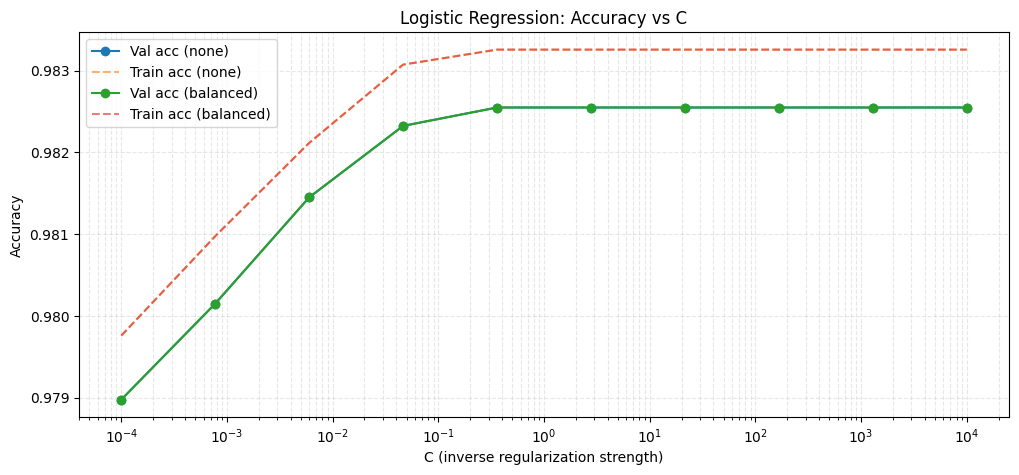

In [12]:
plt.figure(figsize=(12, 5))

for cw_name, _ in settings:
    subset = [r for r in val_results if r[1] == cw_name]
    Cs = np.array([r[0] for r in subset])
    tr = np.array([r[2] for r in subset])
    va = np.array([r[3] for r in subset])

    order = np.argsort(Cs)
    Cs, tr, va = Cs[order], tr[order], va[order]

    plt.plot(Cs, va, marker="o", label=f"Val acc ({cw_name})")
    plt.plot(Cs, tr, linestyle="--", alpha=0.6, label=f"Train acc ({cw_name})")

plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Accuracy")
plt.title("Logistic Regression: Accuracy vs C")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.show()

In [13]:
best = max(val_results, key=lambda t: t[3])  # maximize val_acc
best_C, best_cw_name, best_train_acc, best_val_acc = best
best_cw = "balanced" if best_cw_name == "balanced" else None

final_lr = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="liblinear",
    class_weight=best_cw,
    max_iter=2000,
    random_state=1,
)
final_lr.fit(X_train_scaled, y_train)

print("Best setting:", best)

Best setting: (np.float64(0.3593813663804626), 'none', 0.9832583333333333, 0.98255)


In [14]:
y_test_pred = final_lr.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Benign", "DDoS"], digits=4))


Test Accuracy: 0.9873

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9965    0.9780    0.9872     20000
        DDoS     0.9784    0.9966    0.9874     20000

    accuracy                         0.9873     40000
   macro avg     0.9875    0.9873    0.9873     40000
weighted avg     0.9875    0.9873    0.9873     40000



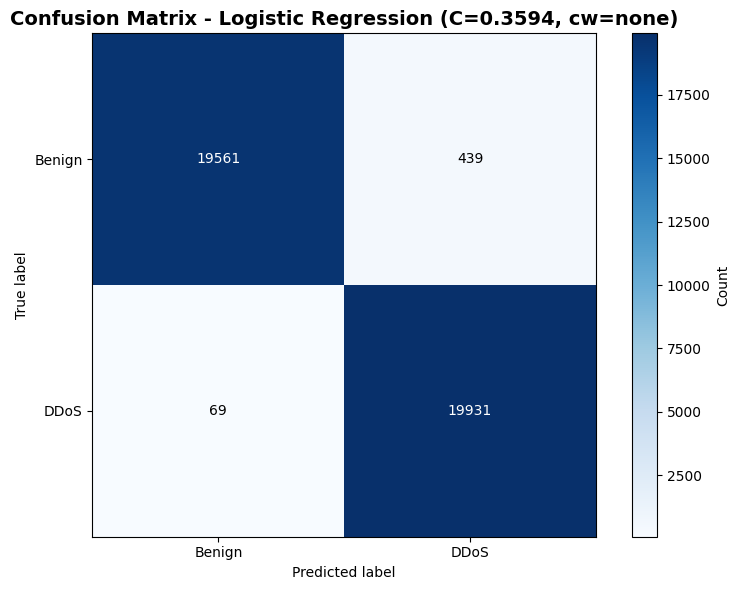

In [15]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix - Logistic Regression (C={best_C:.4g}, cw={best_cw_name})", fontsize=14, fontweight="bold")
plt.colorbar(label="Count")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xticks([0, 1], ["Benign", "DDoS"])
plt.yticks([0, 1], ["Benign", "DDoS"])
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

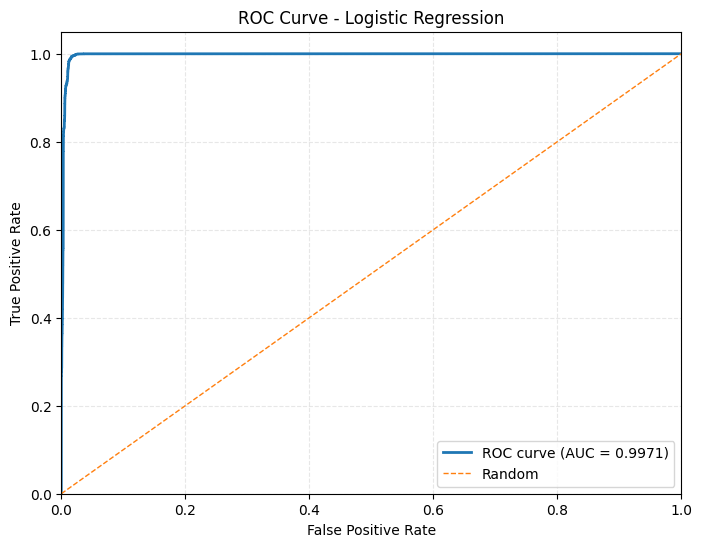

ROC AUC: 0.9970943075


In [16]:
y_test_proba = final_lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

print("ROC AUC:", roc_auc)

In [17]:
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

cv_scores = cross_val_score(final_lr, X_trainval, y_trainval, cv=5, scoring="accuracy")

print(f"Scores per fold: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Scores per fold: [0.987375   0.987375   0.98609375 0.98628125 0.98715625]
Mean CV Accuracy: 0.9869 (+/- 0.0006)


In [18]:
print(f"Dataset Size: {len(X)} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: Benign (0), DDoS (1)")
print(f"\nBest C: {best_C:.4g}")
print(f"Best class_weight: {best_cw_name}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"CV Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Dataset Size: 200000 samples
Features: 79
Classes: Benign (0), DDoS (1)

Best C: 0.3594
Best class_weight: none
Validation Accuracy: 0.9826
Test Accuracy: 0.9873
ROC AUC: 0.9971
CV Mean Accuracy: 0.9869 (+/- 0.0006)
